<a href="https://colab.research.google.com/github/ChanchalSaha48/nlp-learning-journey/blob/main/03_machine_learning%20/02_Naive_Bayes/%20IMDb_movire_review_using_Naive_Bayes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install opendatasets

In [ ]:
import opendatasets as od

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

## Load Dataset

In [ ]:
od.download('https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews')

Skipping, found downloaded files in "./imdb-dataset-of-50k-movie-reviews" (use force=True to force download)


In [ ]:
path='/content/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv'
df=pd.read_csv(path)

In [ ]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


## Preprocessing

In [ ]:
from bs4 import BeautifulSoup

In [ ]:
def preprocessing(text):
  text=BeautifulSoup(text,'html.parser').get_text()
  text=text.lower()
  return text


In [ ]:
df['review']=df['review'].apply(preprocessing)


In [ ]:
df['label']=df['sentiment'].map({
    'negative':0,
    'positive':1
})

In [ ]:
df.head()

,review,sentiment,label
0,one of the other reviewers has mentioned that ...,positive,1
1,a wonderful little production. the filming tec...,positive,1
2,i thought this was a wonderful way to spend ti...,positive,1
3,basically there's a family where a little boy ...,negative,0
4,"petter mattei's ""love in the time of money"" is...",positive,1


## Spliting Dataset

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(
    df['review'],df['label'],test_size=0.2,random_state=42,stratify=df['label']
)

In [ ]:
print("Trianing shape: ",x_train.shape)
print("Testing shape: ",x_test.shape)

Trianing shape:  (40000,)
Testing shape:  (10000,)


## TF-IDF

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf=TfidfVectorizer(max_features=20000)

In [ ]:
x_train_tfidf=tfidf.fit_transform(x_train)

In [ ]:
x_test_tfidf=tfidf.transform(x_test)

## Train Model

In [ ]:
model=MultinomialNB()

In [ ]:
model.fit(x_train_tfidf,y_train)

MultinomialNB()

In [ ]:
y_pred=model.predict(x_test_tfidf)

In [ ]:
acc=accuracy_score(y_test,y_pred)
pre=precision_score(y_test,y_pred)
rec=recall_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)

In [ ]:
print("Accuracy Score: ",acc)
print("Precision Score: ",pre)
print("Recall Score ",rec)
print("F1-Score: ",f1)

Accuracy Score:  0.8615
Precision Score:  0.8692543411644535
Recall Score  0.851
F1-Score:  0.8600303183425972


In [ ]:
cm=confusion_matrix(y_test,y_pred)

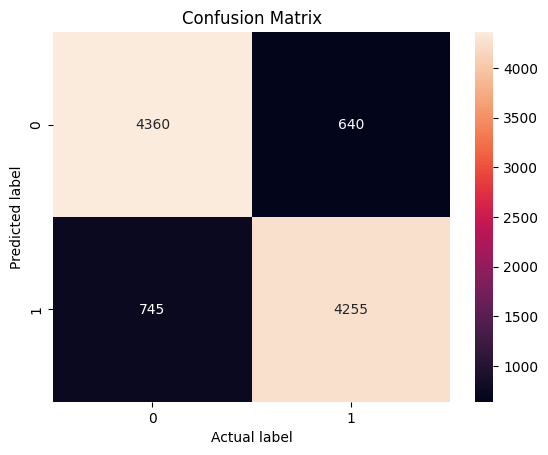

In [ ]:
sns.heatmap(cm,annot=True,fmt='d')
plt.xlabel("Actual label")
plt.ylabel("Predicted label")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
cm

array([[4360,  640],
       [ 745, 4255]])

In [ ]:
tfidf_bi=TfidfVectorizer(
    ngram_range=(1,2),
    max_features=20000
)

In [ ]:
x_train_bi=tfidf_bi.fit_transform(x_train)
x_test_bi=tfidf_bi.transform(x_test)

In [ ]:
model_bi=MultinomialNB()

In [ ]:
model_bi.fit(x_train_bi,y_train)

MultinomialNB()

In [ ]:
y_pred_bi=model_bi.predict(x_test_bi)

In [ ]:
acc_bi=accuracy_score(y_test,y_pred_bi)
pre_bi=precision_score(y_test,y_pred_bi)
rec_bi=recall_score(y_test,y_pred_bi)
f1_bi=f1_score(y_test,y_pred_bi)

In [ ]:
print("Accuracy for bigram: ",acc_bi)
print("Precision for bigram: ",pre_bi)
print("Recall for bigram: ",rec_bi)
print("F1-Score for bigram: ",f1_bi)

Accuracy for bigram:  0.8759
Precision for bigram:  0.8678802113916618
Recall for bigram:  0.8868
F1-Score for bigram:  0.8772381046592146


In [ ]:
tfidf_tri=TfidfVectorizer(
    ngram_range=(1,3),
    max_features=20000
)


In [ ]:
x_train_tri=tfidf_tri.fit_transform(x_train)
x_test_tri=tfidf_tri.transform(x_test)

In [ ]:
model_tri=MultinomialNB()


In [ ]:
model_tri.fit(x_train_tri,y_train)


MultinomialNB()

In [ ]:
y_pred_tri=model_tri.predict(x_test_tri)

In [ ]:
acc_tri=accuracy_score(y_test,y_pred_tri)
pre_tri=precision_score(y_test,y_pred_tri)
rec_tri=recall_score(y_test,y_pred_tri)
f1_tri=f1_score(y_test,y_pred_tri)

In [ ]:
print("Accuracy for trigram: ",acc_tri)
print("Precision for trigram: ",pre_tri)
print("Recall for trigram: ",rec_tri)
print("F1-score for trigram: ",f1_tri)

Accuracy for trigram:  0.8766
Precision for trigram:  0.8642166344294003
Recall for trigram:  0.8936
F1-score for trigram:  0.8786627335299901


In [ ]:
ct=[]


In [ ]:
ct.append(["Uni",acc,pre,rec,f1])
ct.append(["Uni+bi",acc_bi,pre_bi,rec_bi,f1_bi])
ct.append(["Uni+bi+tri",acc_tri,pre_tri,rec_tri,f1_tri])

In [ ]:
comparision_table=pd.DataFrame(ct,columns=['n-gram','Accuracy','Precision','Recall','F1-Score'])

In [ ]:
comparision_table

,n-gram,Accuracy,Precision,Recall,F1-Score
0,Uni,0.8615,0.869254,0.8510,0.860030
1,Uni+bi,0.8759,0.867880,0.8868,0.877238
2,Uni+bi+tri,0.8766,0.864217,0.8936,0.878663
